In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from runs import multi_subject_experiments, test_experiments
import os
import pickle as pkl
from utils_multisubject import read_files, apply_features, create_window_df

In [4]:
# Source Folders
source_folder = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/LabeledData"

# Channels Used
channels = ["L_O_DSphi", "L_D_DSphi", "R_D_DSphi", "R_O_DSphi",	"L_O_DSI",	"R_D_DSI",	"R_O_DSI",	"L_D_DSI"]
# channels = ['L_D_DSphi_L_O_DSphi_diff', 'R_D_DSphi_R_O_DSphi_diff', 'L_D_DSI_L_O_DSI_diff', 'R_D_DSI_R_O_DSI_diff']

# Features To Remove
remove_features = []

# Label Mapping
labels_for_windows = ["discrete_optimal", "binary_optimal", "continuous_optimal"]
final_labels = {"discrete": "discrete_label",
            "binary": "binary_label",
            "continuous": "continuous_label"}

In [5]:
# Chosen Experiment from runs.py
experiment_number = 5

# Save Model Metrics
save_results = False

# Load Windowed Data
seconds = 7 # Duration of each window in seconds
window_size = int(seconds*5.25)
windowedData = []

# Load Training List and Conditions from runs.py
participant_list, conditions_list, experiment_name = multi_subject_experiments[experiment_number].values()

participants = str(participant_list)
conditions = str(conditions_list)[2:-2]

print("Experiment Name: ", experiment_name)
print("\nTraining List: ", participants, "\nTraining Conditions: ", conditions) 

Experiment Name:  multiSubject

Training List:  [2, 5, 6, 9, 10, 11, 13, 15, 16, 17, 18, 19, 20, 24] 
Training Conditions:  RW


In [6]:
# Remove Random Participants for Cross-Validation
number_of_participants = len(participant_list)

number_of_participants_for_validation = number_of_participants // 5

random_indices = np.random.choice(number_of_participants, 
                                   number_of_participants_for_validation,
                                   replace=False)

train_participants = [participant_list[i] for i in range(number_of_participants) if i not in random_indices]
validation_participants = [participant_list[i] for i in random_indices]

print("Validation Participants: ", validation_participants)
print("Training Participants: ", train_participants)


Validation Participants:  [13, 15]
Training Participants:  [2, 5, 6, 9, 10, 11, 16, 17, 18, 19, 20, 24]


In [7]:
def add_new_features(data, channels):
    """
    Add new features to the data.
    """
    column_pairs = [["L_D_DSphi", "L_O_DSphi"], ["R_D_DSphi", "R_O_DSphi"],
                    ["L_D_DSI", "L_O_DSI"], ["R_D_DSI", "R_O_DSI"]]
    
    df_data_train = pd.DataFrame()

    for key in data.keys():
        
        if key not in remove_features:
            # subtract column pairs for each feature
            for pair in column_pairs:
                if pair[0] in data[key].columns and pair[1] in data[key].columns:
                    new_feature_name = f"{pair[0]}_{pair[1]}_diff"
                    data[key][new_feature_name] = data[key][pair[0]] - data[key][pair[1]]

    
    return data

In [8]:
# Read Files for Training Data
train_data = read_files(participant_list=train_participants, source_folder_1 = source_folder, conditions=conditions_list)
val_data = read_files(participant_list=validation_participants, source_folder_1 = source_folder, conditions=conditions_list)

# train_data =  add_new_features(train_data, channels=channels)
# print(train_data["17RW"].keys())

In [9]:
df_data_train = pd.DataFrame()
df_labels_train = pd.DataFrame()

for key in train_data.keys():
    window_data, window_labels = create_window_df(train_data[key], window_size=window_size, step_size=1, labels=labels_for_windows, features=channels)
    print(key, "is done")
    df_data_train = pd.concat([df_data_train, window_data], ignore_index=True)
    df_labels_train = pd.concat([df_labels_train, window_labels], ignore_index=True)


['discrete_optimal', 'binary_optimal', 'continuous_optimal']
2RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
11RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
17RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
24RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
19RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
9RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
5RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
18RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
16RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
6RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
20RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
10RW is done


In [10]:
df_data_train.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)


In [11]:
# df_data_val = pd.DataFrame()
# df_labels_val = pd.DataFrame()

# for key in val_data.keys():
#     window_data, window_labels = create_window_df(val_data[key], window_size=window_size, step_size=1, labels=labels_for_windows, features=channels)
#     print(key, "is done")
#     df_data_val = pd.concat([df_data_val, window_data], ignore_index=True)
#     df_labels_val = pd.concat([df_labels_val, window_labels], ignore_index=True)

# df_data_val.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)
# print(df_labels_val.columns)

In [16]:
def create_train_data(df_data, df_labels):
    df = pd.concat([df_data.reset_index(drop=True), df_labels.reset_index(drop=True)], axis=1)

    # Downsample discrete/multi-class labels
    min_discrete = df['discrete_label'].value_counts().min()
    print("Minimum count for discrete_label:", min_discrete)
    df_balanced_discrete = df.groupby('discrete_label', group_keys=False).apply(lambda x: x.sample(min_discrete, random_state=42))

    # Downsample binary labels
    min_binary = df['binary_label'].value_counts().min()
    print("Minimum count for binary_label:", min_binary)
    df_balanced_binary = df.groupby('binary_label', group_keys=False).apply(lambda x: x.sample(min_binary, random_state=42))

    # Separate features and labels
    X_binary = df_balanced_binary[df_data.columns]
    X_discrete = df_balanced_discrete[df_data.columns]
    y_discrete = df_balanced_discrete['discrete_label']
    y_binary = df_balanced_binary['binary_label']
    y_continuous = df['continuous_label']

    return df, X_binary, X_discrete, y_binary, y_discrete, y_continuous

x_continuous, x_binary, x_discrete, y_binary, y_discrete, y_continuous = create_train_data(df_data=df_data_train, df_labels=df_labels_train)
print("Binary label counts:\n", y_binary.value_counts())
print("Discrete label counts:\n", y_discrete.value_counts())

Minimum count for discrete_label: 2271
Minimum count for binary_label: 5418
Binary label counts:
 binary_label
0    5418
1    5418
Name: count, dtype: int64
Discrete label counts:
 discrete_label
0    2271
1    2271
2    2271
Name: count, dtype: int64


In [13]:
x_binary

,L_O_DSphi_Mean,L_O_DSphi_Std,L_O_DSphi_Slope,L_O_DSphi_Intercept,L_O_DSphi_Kurtosis,L_O_DSphi_Skewness,L_D_DSphi_Mean,L_D_DSphi_Std,L_D_DSphi_Slope,L_D_DSphi_Intercept,...,R_O_DSI_Slope,R_O_DSI_Intercept,R_O_DSI_Kurtosis,R_O_DSI_Skewness,L_D_DSI_Mean,L_D_DSI_Std,L_D_DSI_Slope,L_D_DSI_Intercept,L_D_DSI_Kurtosis,L_D_DSI_Skewness
9306,-2.152296,0.541576,1.629504,21.007174,-1.214831,-0.099140,0.390431,0.117953,-60.520291,41.129025,...,7.910719,18.635519,-1.670258,0.160908,0.012659,0.033368,-226.501822,20.367337,-1.247965,-0.350788
3403,-0.089318,1.005130,7.361531,18.157517,-0.536789,0.884212,-0.174656,0.189465,-38.895564,10.706648,...,-23.291048,17.001280,-0.604441,-0.936370,-0.910352,0.309302,-10.035026,8.364592,-1.448550,0.221768
803,-1.123827,0.510430,-8.744961,7.672173,-1.328382,-0.127870,0.664256,0.090115,61.986882,-23.675163,...,-15.384480,48.153585,-0.081766,1.151913,0.155552,0.069096,106.378283,0.952685,1.873678,-1.695497
744,5.287032,0.581601,4.225012,-4.837773,-1.465124,0.018061,-0.046729,0.131124,-62.683562,14.570882,...,-1.605723,14.358434,-1.493076,0.214381,0.130641,0.050976,-157.334728,38.054377,-0.774296,-0.706862
10083,4.011571,1.397510,-4.092182,33.916077,-0.903132,0.654539,-0.816690,0.271744,25.945120,38.689127,...,-52.516059,42.425535,-1.471416,0.192442,-0.507494,0.044445,-42.329320,-3.981883,-0.982000,0.363491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10796,-2.581966,1.182545,-7.469929,-1.787105,0.021430,1.174424,0.610298,0.249172,36.683530,-4.887900,...,62.465042,-7.959023,-1.531979,0.146273,0.216558,0.018375,210.270689,-28.035738,1.360681,1.371877
1887,-0.168339,0.995891,-4.647918,16.717574,-0.993479,0.230910,-0.151252,0.268680,30.496625,22.112674,...,-132.008922,13.225163,1.227466,-1.293753,-0.375219,0.041265,-200.216096,-57.624866,-0.711052,0.600055
9587,2.324717,1.246129,-1.991942,22.130700,-1.617284,0.020826,-0.139283,0.267475,14.811344,19.562975,...,-60.936417,-23.985194,-1.390270,0.233813,-0.265395,0.076634,128.081716,51.492233,0.227540,1.047745
433,-0.857054,0.623978,11.551494,27.400254,-0.550966,-0.125997,0.240510,0.101629,-71.270657,34.641295,...,-31.812966,4.712238,-1.542908,-0.021610,-0.011698,0.022114,-157.922762,15.652689,-0.299381,-0.433034


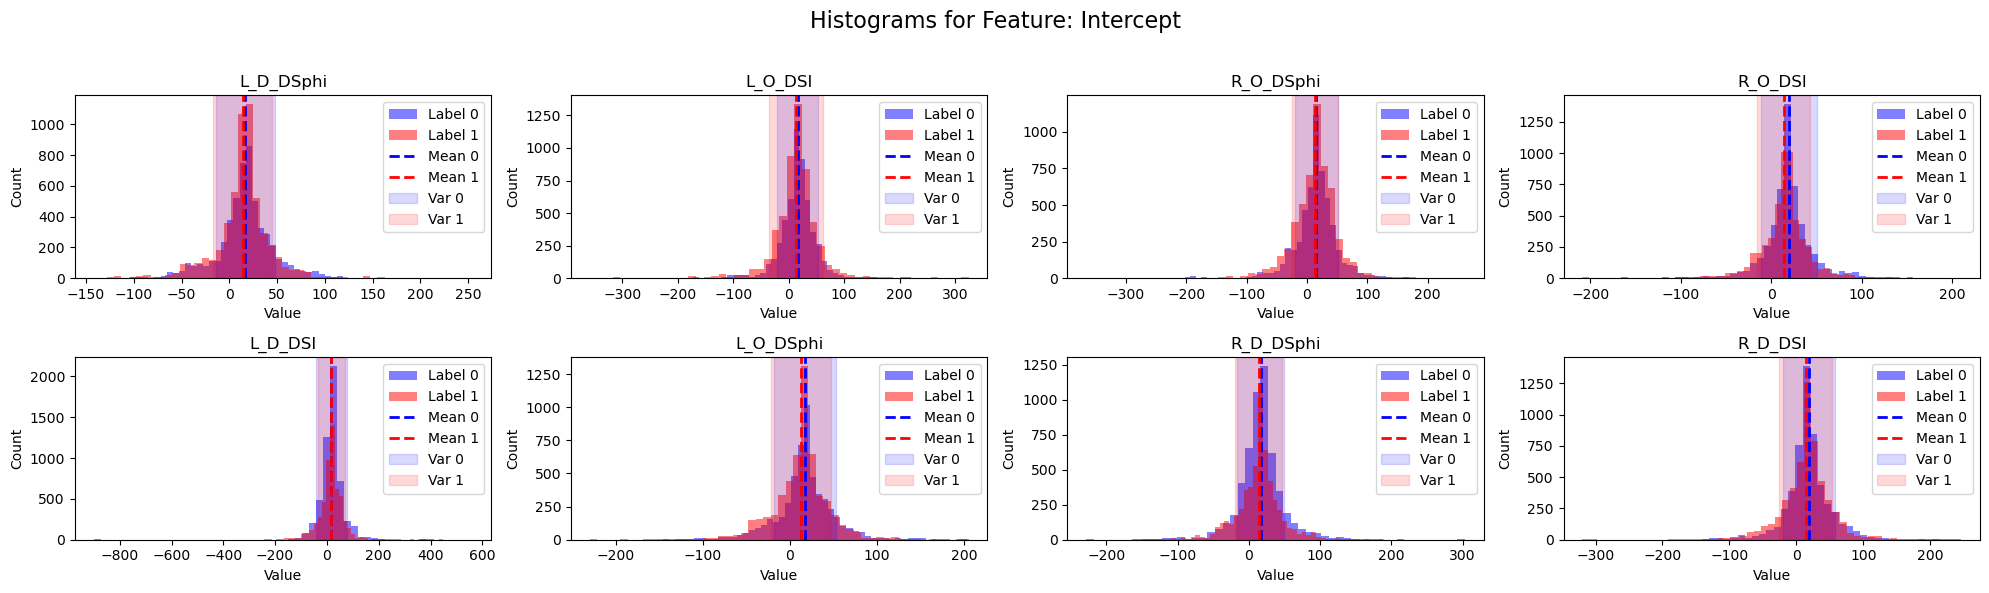

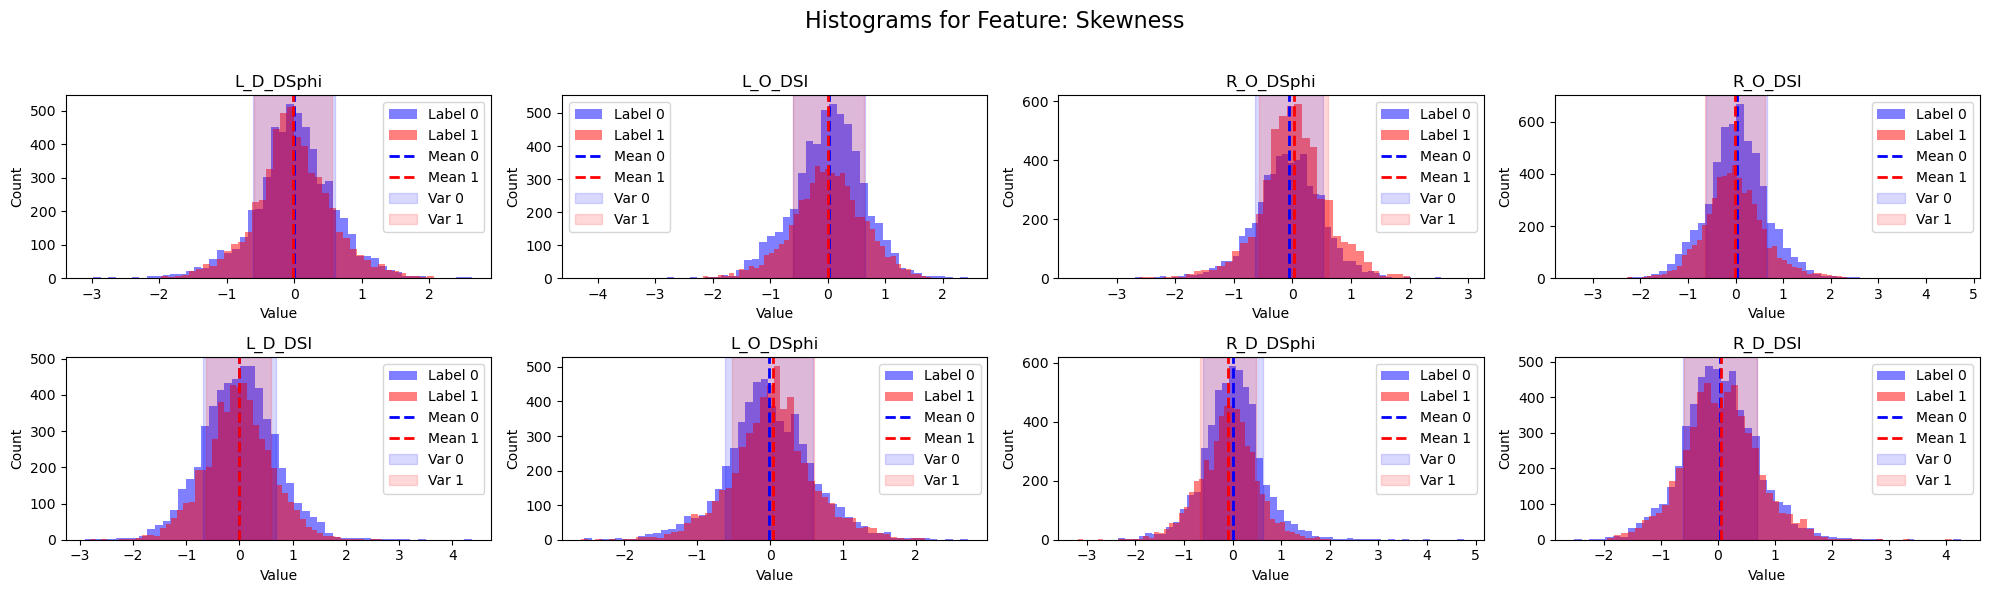

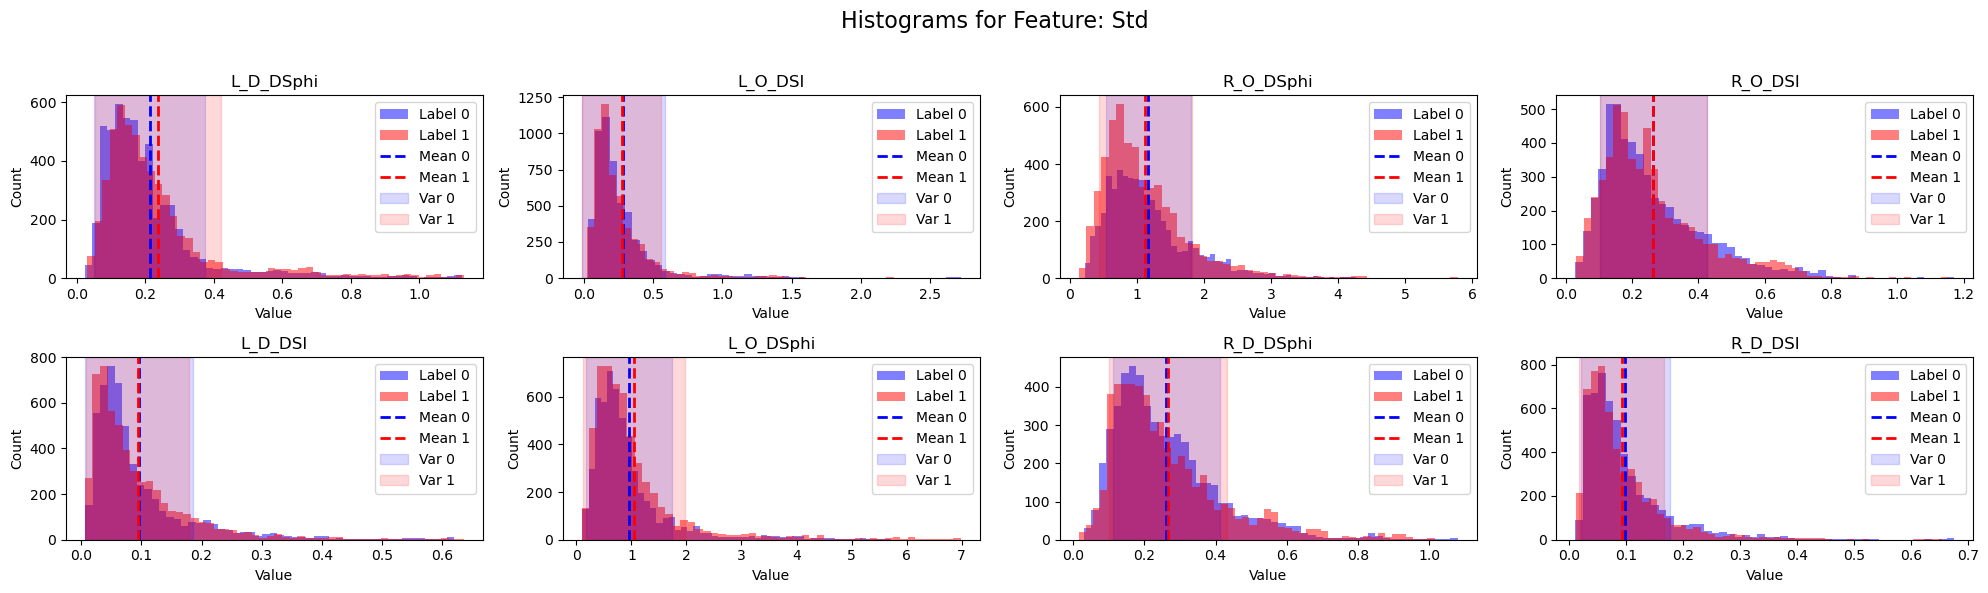

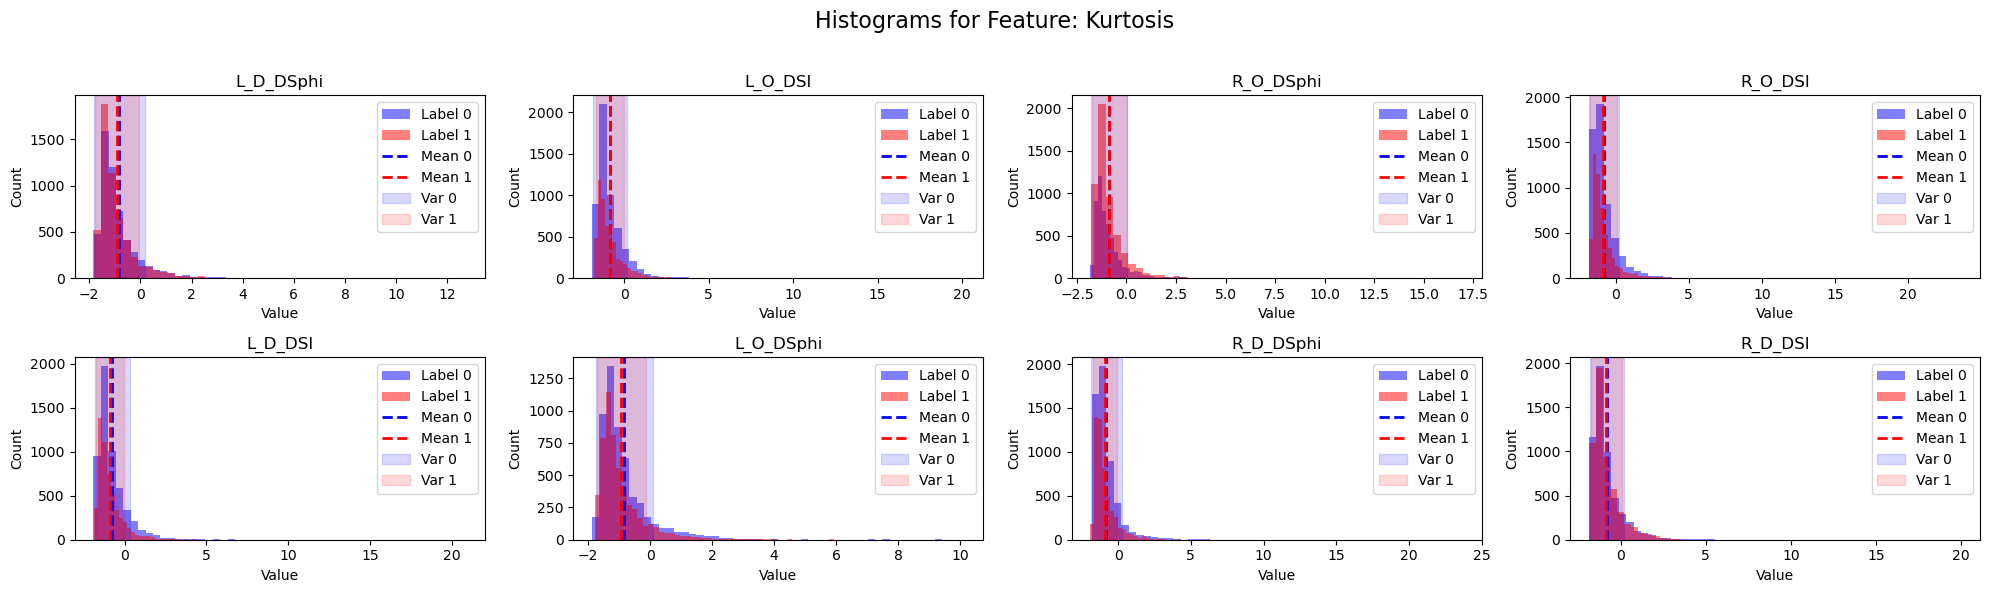

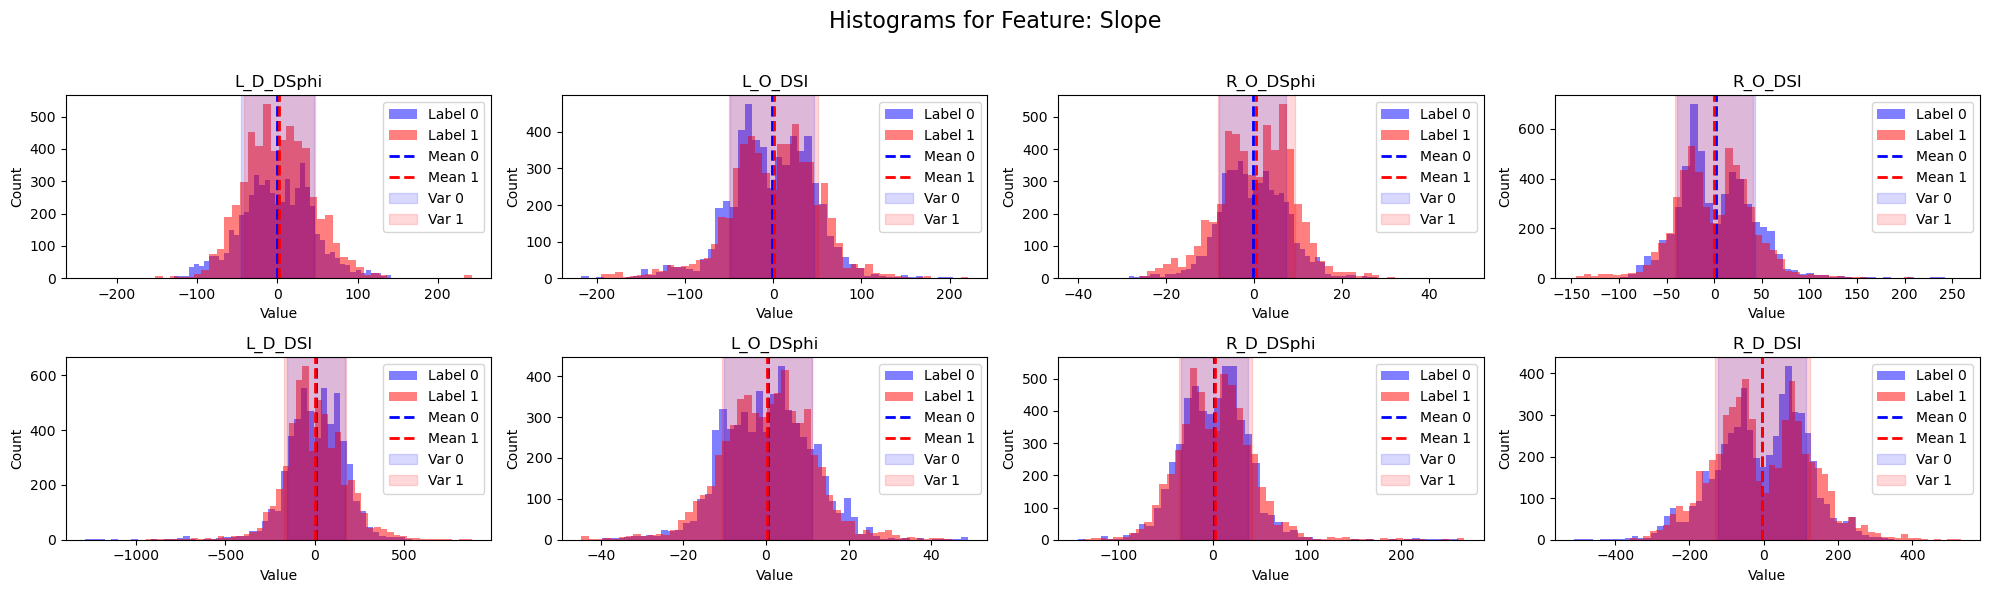

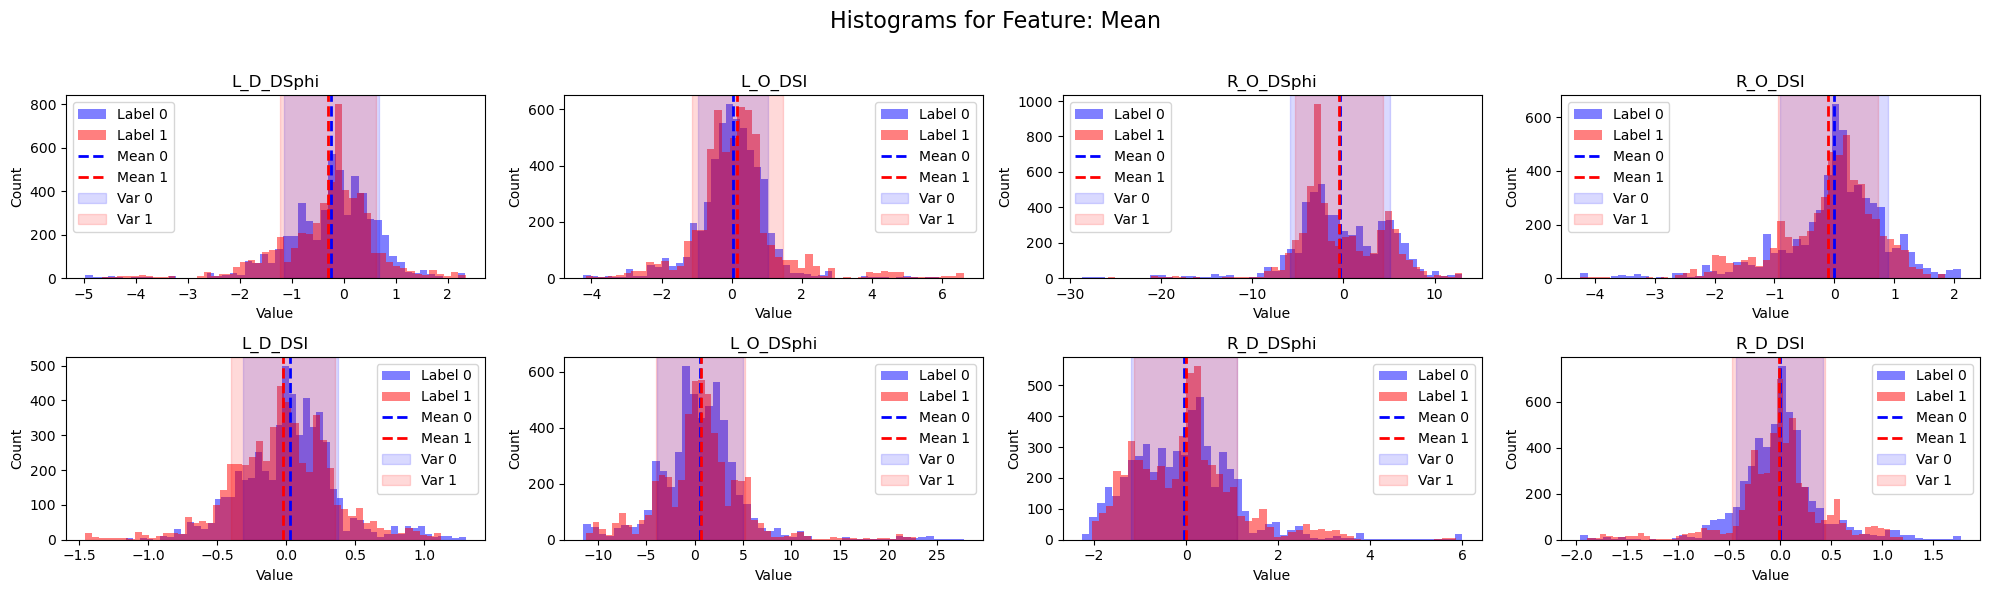

In [32]:
def plot_binary_data(df_data, df_labels, title="Binary Data Plot"):
    features_list = df_data.columns
    features = [col.split('_')[-1] for col in features_list]
    features = list(set(features))
    sensors = [col.split('_')[:3] for col in features_list]
    sensors = ['_'.join(sensor) for sensor in sensors]
    unique_sensors = list(set(sensors))
    num_features = len(features)
    num_sensors = len(unique_sensors)

    for i, feature in enumerate(features):
        fig, axes = plt.subplots(nrows=2, ncols=num_sensors//2, figsize=(20, 6), sharex=False)
        fig.suptitle(f"Histograms for Feature: {feature}", fontsize=16)
        for idx, sensor in enumerate(unique_sensors):
            row = idx // (num_sensors // 2)
            col = idx % (num_sensors // 2)
            ax = axes[row, col]
            col_name = sensor + "_" + feature
            if col_name in df_data.columns:
                # Remove outliers for label 0
                data_0 = df_data.loc[df_labels == 0, col_name]
                mean_0 = data_0.mean()
                std_0 = data_0.std()
                var_0 = data_0.var()
                # data_0 = data_0[(data_0 > mean_0 - 3*std_0) & (data_0 < mean_0 + 3*std_0)]
                # Remove outliers for label 1
                data_1 = df_data.loc[df_labels == 1, col_name]
                mean_1 = data_1.mean()
                std_1 = data_1.std()
                var_1 = data_1.var()
                # data_1 = data_1[(data_1 > mean_1 - 3*std_1) & (data_1 < mean_1 + 3*std_1)]
                # Plot histograms
                ax.hist(data_0, bins=50, alpha=0.5, label="Label 0", color="blue")
                ax.hist(data_1, bins=50, alpha=0.5, label="Label 1", color="red")
                # Plot means
                ax.axvline(mean_0, color="blue", linestyle="dashed", linewidth=2, label="Mean 0")
                ax.axvline(mean_1, color="red", linestyle="dashed", linewidth=2, label="Mean 1")
                # Plot variance as shaded area (mean ± std)
                ax.axvspan(mean_0 - std_0, mean_0 + std_0, color="blue", alpha=0.15, label="Var 0")
                ax.axvspan(mean_1 - std_1, mean_1 + std_1, color="red", alpha=0.15, label="Var 1")
                ax.set_title(sensor)
                ax.set_xlabel("Value")
                ax.set_ylabel("Count")
                ax.legend()
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

plot_binary_data(x_binary, y_binary, title="Binary Data Plot")


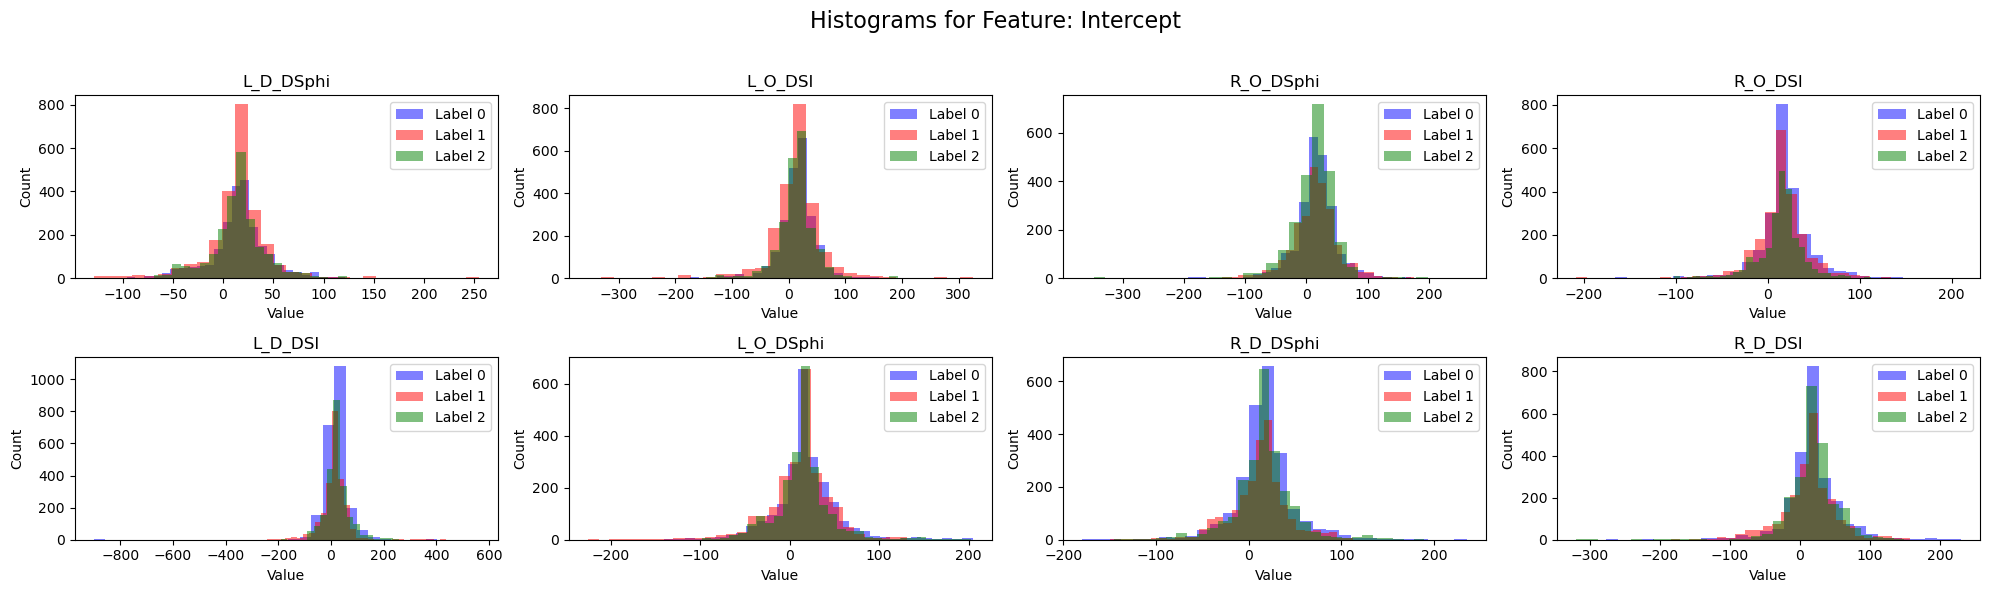

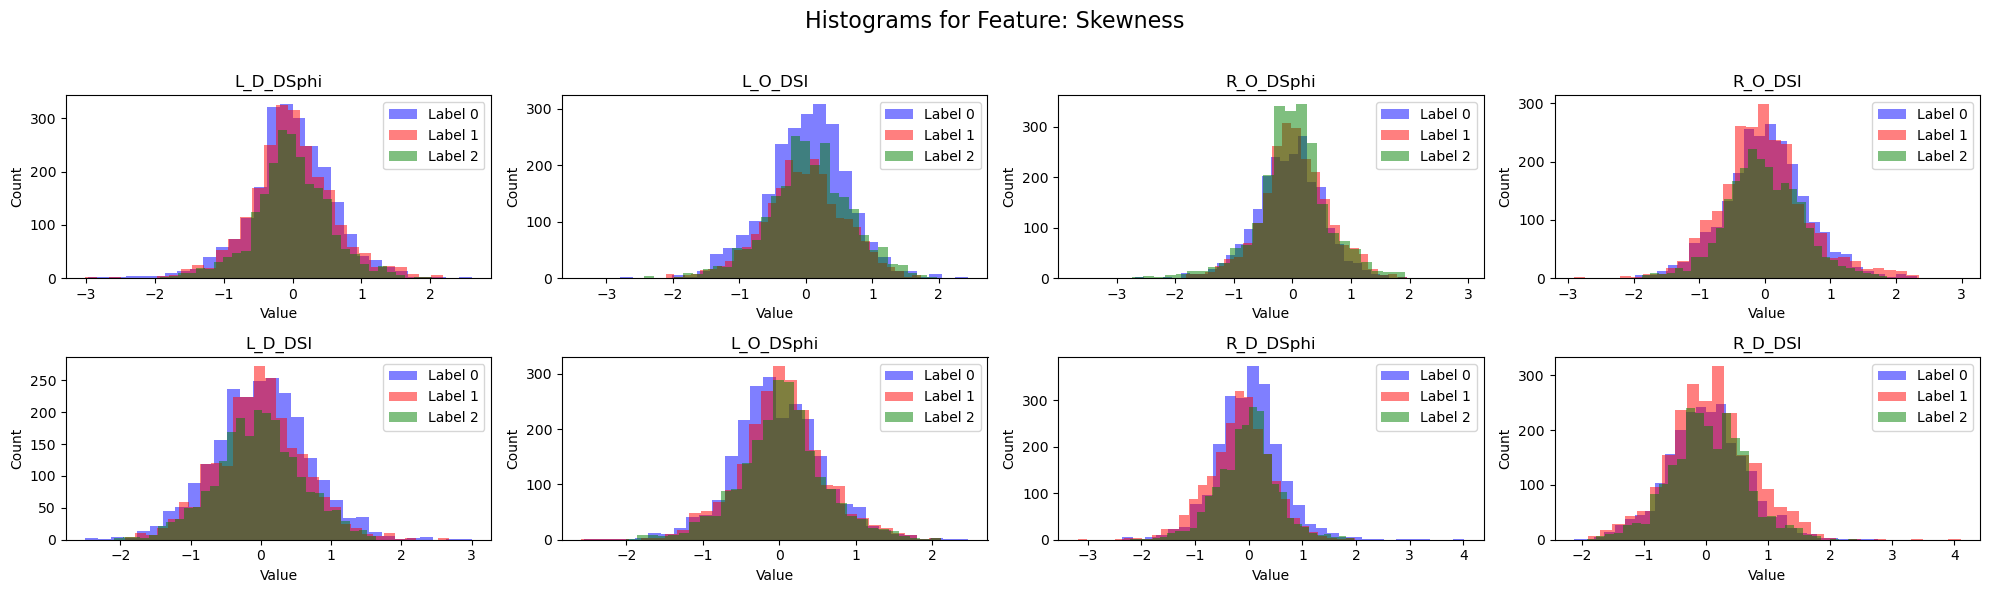

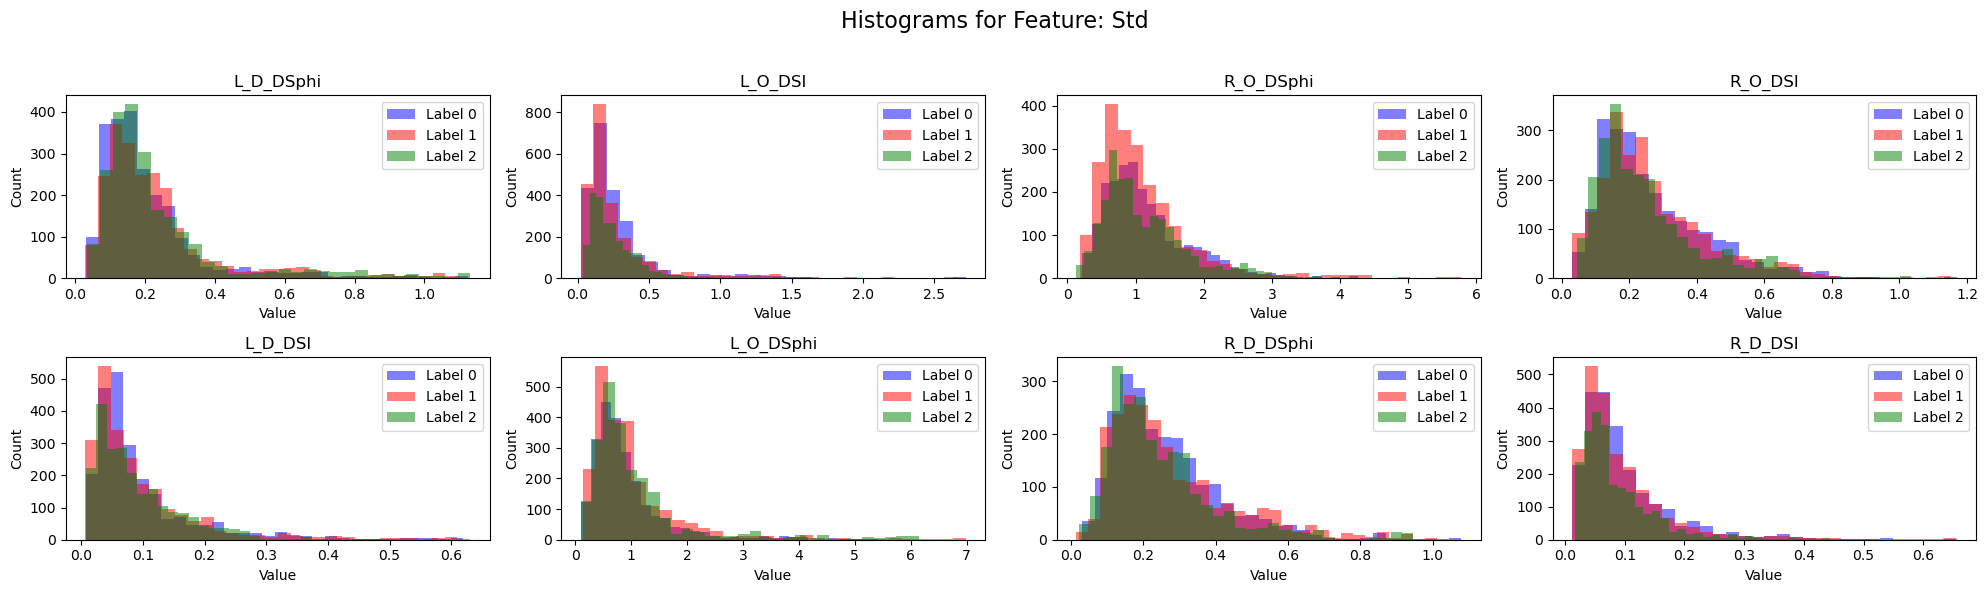

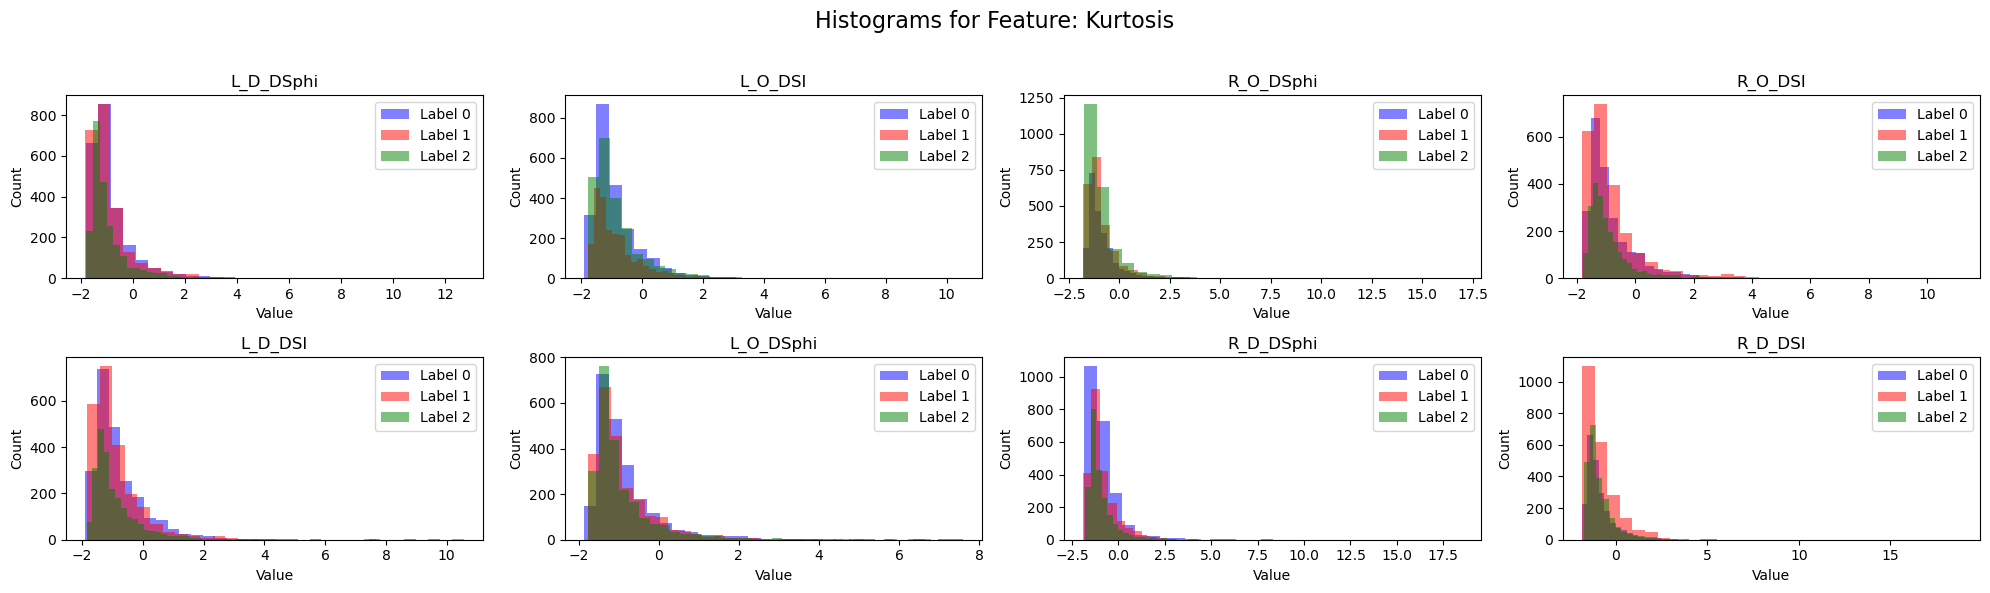

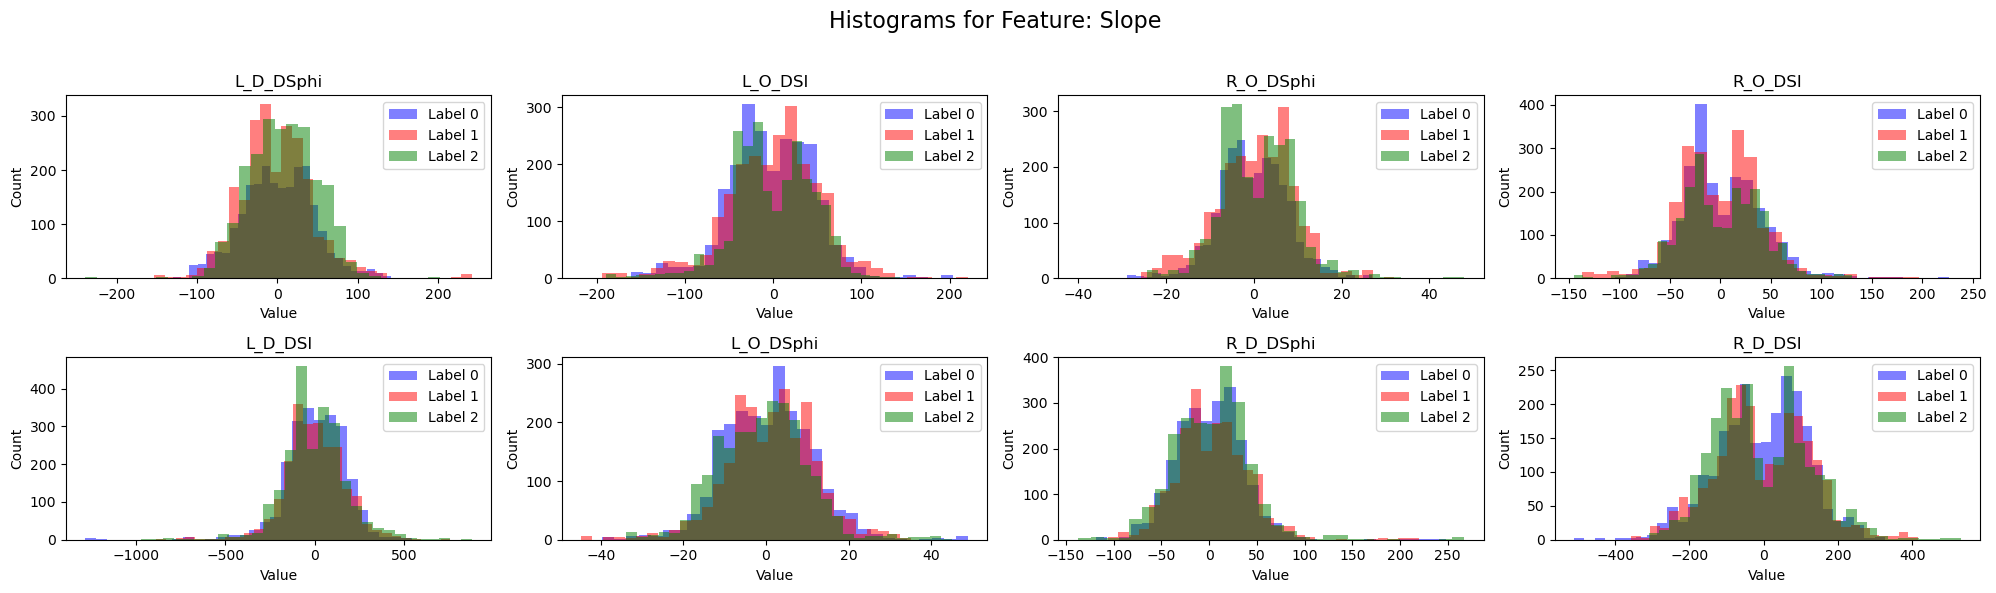

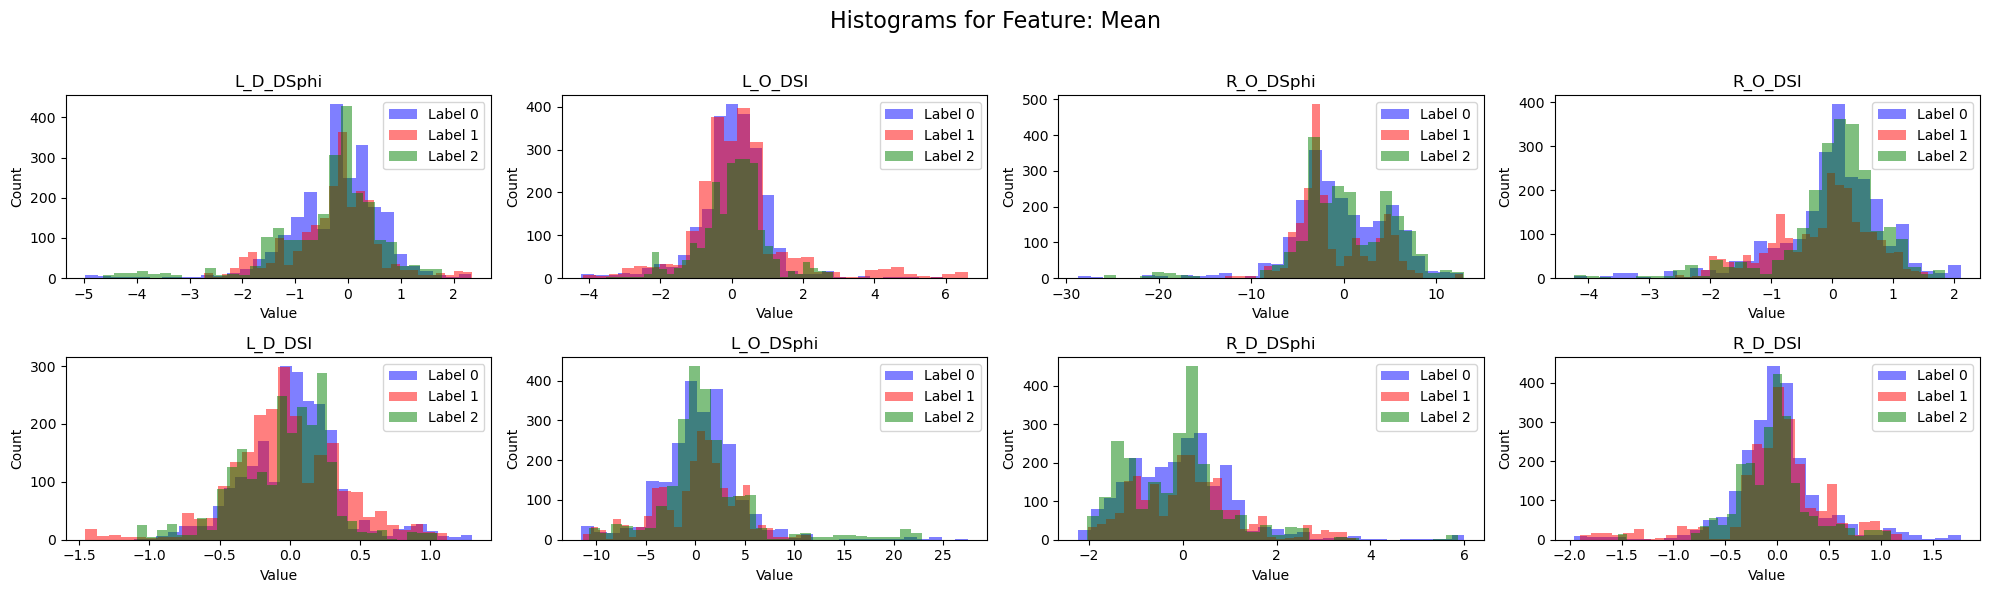

In [15]:
def plot_discrete_data(df_data, df_labels, title="Discrete Data Plot"):
    #split the column name to get the unique feature at the end
    features_list = df_data.columns
    features = [col.split('_')[-1] for col in features_list]
    features = list(set(features))  # Get unique channels

    # get each sensor location, or the first three parts of the split column
    sensors = [col.split('_')[:3] for col in features_list]
    sensors = ['_'.join(sensor) for sensor in sensors]  # Join back to
    unique_sensors = list(set(sensors))  # Get unique sensors

    # print a plot for each feature with left sensors on the top and right sensors on the bottom
    num_features = len(features)
    num_sensors = len(unique_sensors)   
    
    for i, feature in enumerate(features):
        fig, axes = plt.subplots(nrows=2, ncols=num_sensors//2, figsize=(20, 6), sharex=False)
        fig.suptitle(f"Histograms for Feature: {feature}", fontsize=16)
        for idx, sensor in enumerate(unique_sensors):
            row = idx // (num_sensors // 2)
            col = idx % (num_sensors // 2)
            ax = axes[row, col]
            col_name = sensor + "_" + feature
            if col_name in df_data.columns:
                # Plot histogram for label 0
                data_0 = df_data.loc[df_labels == 0, col_name]
                ax.hist(data_0, bins=30, alpha=0.5, label="Label 0", color="blue")
                # Plot histogram for label 1
                data_1 = df_data.loc[df_labels == 1, col_name]
                ax.hist(data_1, bins=30, alpha=0.5, label="Label 1", color="red")

                data_2 = df_data.loc[df_labels == 2, col_name]
                ax.hist(data_2, bins=30, alpha=0.5, label="Label 2", color="green")


                ax.set_title(sensor)
                ax.set_xlabel("Value")
                ax.set_ylabel("Count")
                ax.legend()
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()#

plot_discrete_data(x_discrete, y_discrete, title="Discrete Data Plot")
